# Relative Drought — Report Visualisations

Loads cached outputs from the hazard and risk assessment notebooks.
Run both notebooks before executing this script.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm
from pathlib import Path

# --- Configuration -----------------------------------------------------------
SHAPEFILE_PATH = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)  # <-- update to your local shapefile path
OUTPUT_DIR = Path('./data/isimip3b/processed/outputs_hazards')
RISK_DIR   = Path('./data/isimip3b/processed/outputs_risk_districts')
FIG_DIR    = Path('./report_figures/relative_drought')
FIG_DIR.mkdir(parents=True, exist_ok=True)

SCENARIOS = ['historic', 'ssp126_nf', 'ssp126_ff', 'ssp370_nf', 'ssp370_ff']
S_LABEL = {
    'historic':  'Historical (1981-2014)',
    'ssp126_nf': 'SSP1-2.6 NF (2031-2060)',
    'ssp126_ff': 'SSP1-2.6 FF (2071-2100)',
    'ssp370_nf': 'SSP3-7.0 NF (2031-2060)',
    'ssp370_ff': 'SSP3-7.0 FF (2071-2100)',
}
S_SHORT = {
    'historic': 'Hist', 'ssp126_nf': 'S126-NF', 'ssp126_ff': 'S126-FF',
    'ssp370_nf': 'S370-NF', 'ssp370_ff': 'S370-FF',
}
RISK_COLORS = ['#2b83ba', '#abdda4', '#ffffbf', '#fdae61', '#d7191c']
RISK_LABELS = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
risk_cmap   = mcolors.ListedColormap(RISK_COLORS)
risk_norm   = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5, 5.5], risk_cmap.N)

plt.rcParams.update({'font.size': 9, 'figure.dpi': 150, 'axes.titlesize': 9})
print('Configuration ready.')

Configuration ready.


In [2]:
# Load all cached data
districts = gpd.read_file(SHAPEFILE_PATH).to_crs(epsg=4326)
districts['district_name'] = districts['name_en'].str.strip()
districts['oblast_name']   = districts['oblast_en'].str.strip()
districts['_key'] = districts['district_name'] + ' | ' + districts['oblast_name']

hazard_all   = pd.read_csv(OUTPUT_DIR / 'droughthazard_KZ_all_scenarios.csv')
hazard_hist  = pd.read_csv(OUTPUT_DIR / 'droughthazard_KZ_historic.csv')
risk_summary = pd.read_csv(RISK_DIR / 'droughtrisk_KZ_summary_all_scenarios_districts.csv')
composite    = pd.read_csv(RISK_DIR / 'composite_indices_districts.csv', index_col=0)
vuln_df      = pd.read_csv(RISK_DIR / 'vulnerability_indicators_districts.csv', index_col=0)
exp_df       = pd.read_csv(RISK_DIR / 'exposure_indicators_districts.csv', index_col=0)

risk_tables = {}
for scen in SCENARIOS:
    p = RISK_DIR / f'droughtrisk_KZ_{scen}_districts.csv'
    if p.exists():
        df = pd.read_csv(p)
        df['risk_cat'] = pd.to_numeric(df['risk_cat'], errors='coerce')
        risk_tables[scen] = df

# Helpers
def with_col(gdf, keys, vals, col):
    g = gdf.copy()
    g[col] = g['_key'].map(dict(zip(keys, vals)))
    return g

def choropleth(ax, gdf, col, cmap, vmin=None, vmax=None, norm=None, title='', lw=0.2):
    kw = dict(column=col, ax=ax, cmap=cmap, legend=False,
              missing_kwds={'color': 'lightgrey'})
    if norm is not None:
        kw['norm'] = norm
    else:
        kw.update(vmin=vmin, vmax=vmax)
    gdf.plot(**kw)
    gdf.boundary.plot(ax=ax, color='black', linewidth=lw)
    ax.set_title(title, fontsize=8, fontweight='bold')
    ax.set_axis_off()

hist_vals = hazard_all.set_index('district')['historic']
print(f'Districts: {len(districts)}  |  Scenarios in hazard file: '
      f'{[c for c in hazard_all.columns if c != "district"]}')

Districts: 227  |  Scenarios in hazard file: ['historic', 'ssp126_nf', 'ssp126_ff', 'ssp370_nf', 'ssp370_ff']


## Figure 1 — Historical drought hazard intensity

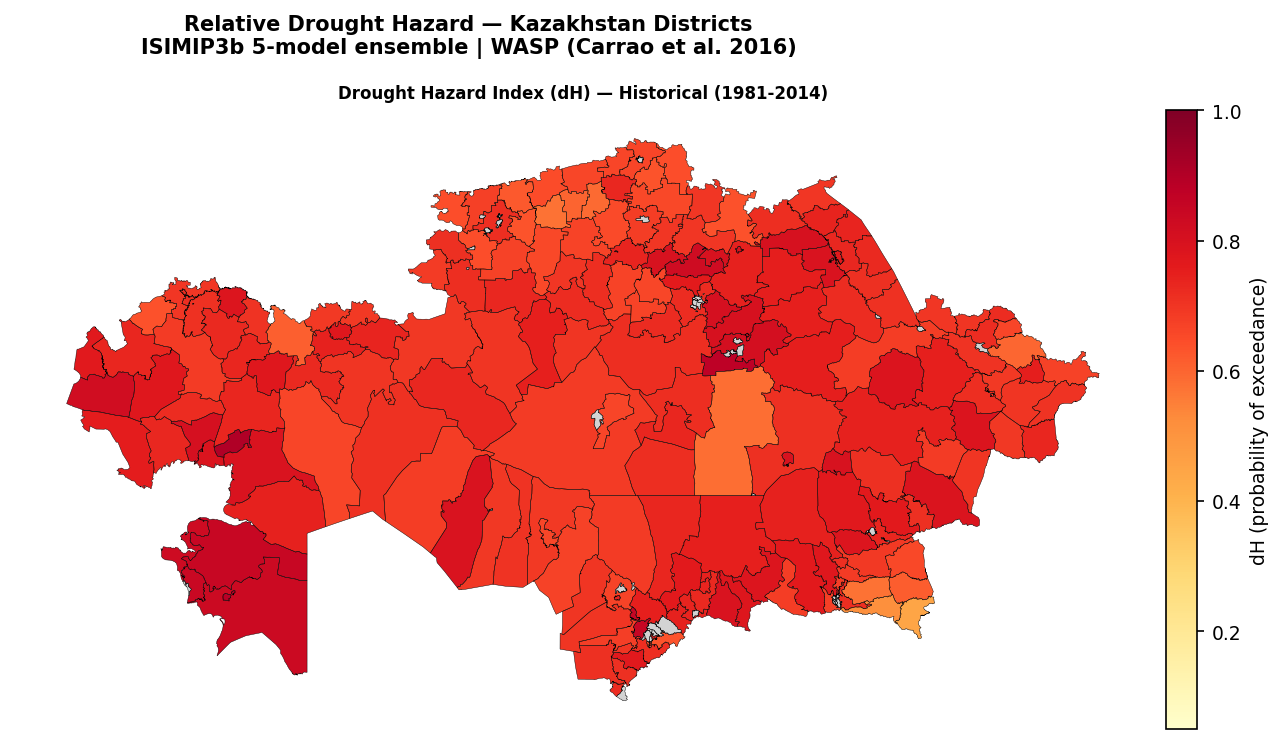

Figure 1 saved.


In [3]:
gdf_h = with_col(districts, hazard_all['district'], hazard_all['historic'], 'dH')

fig, ax = plt.subplots(figsize=(11, 5))
choropleth(ax, gdf_h, 'dH', 'YlOrRd', vmin=0.05, vmax=1.0,
           title='Drought Hazard Index (dH) — Historical (1981-2014)')
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=mcolors.Normalize(0.05, 1.0))
sm.set_array([])
plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.025, pad=0.01,
             label='dH (probability of exceedance)')
fig.suptitle('Relative Drought Hazard — Kazakhstan Districts\n'
             'ISIMIP3b 5-model ensemble | WASP (Carrao et al. 2016)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_dH_historical.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## Figure 2 — Projected change in drought hazard (2x2 panel)

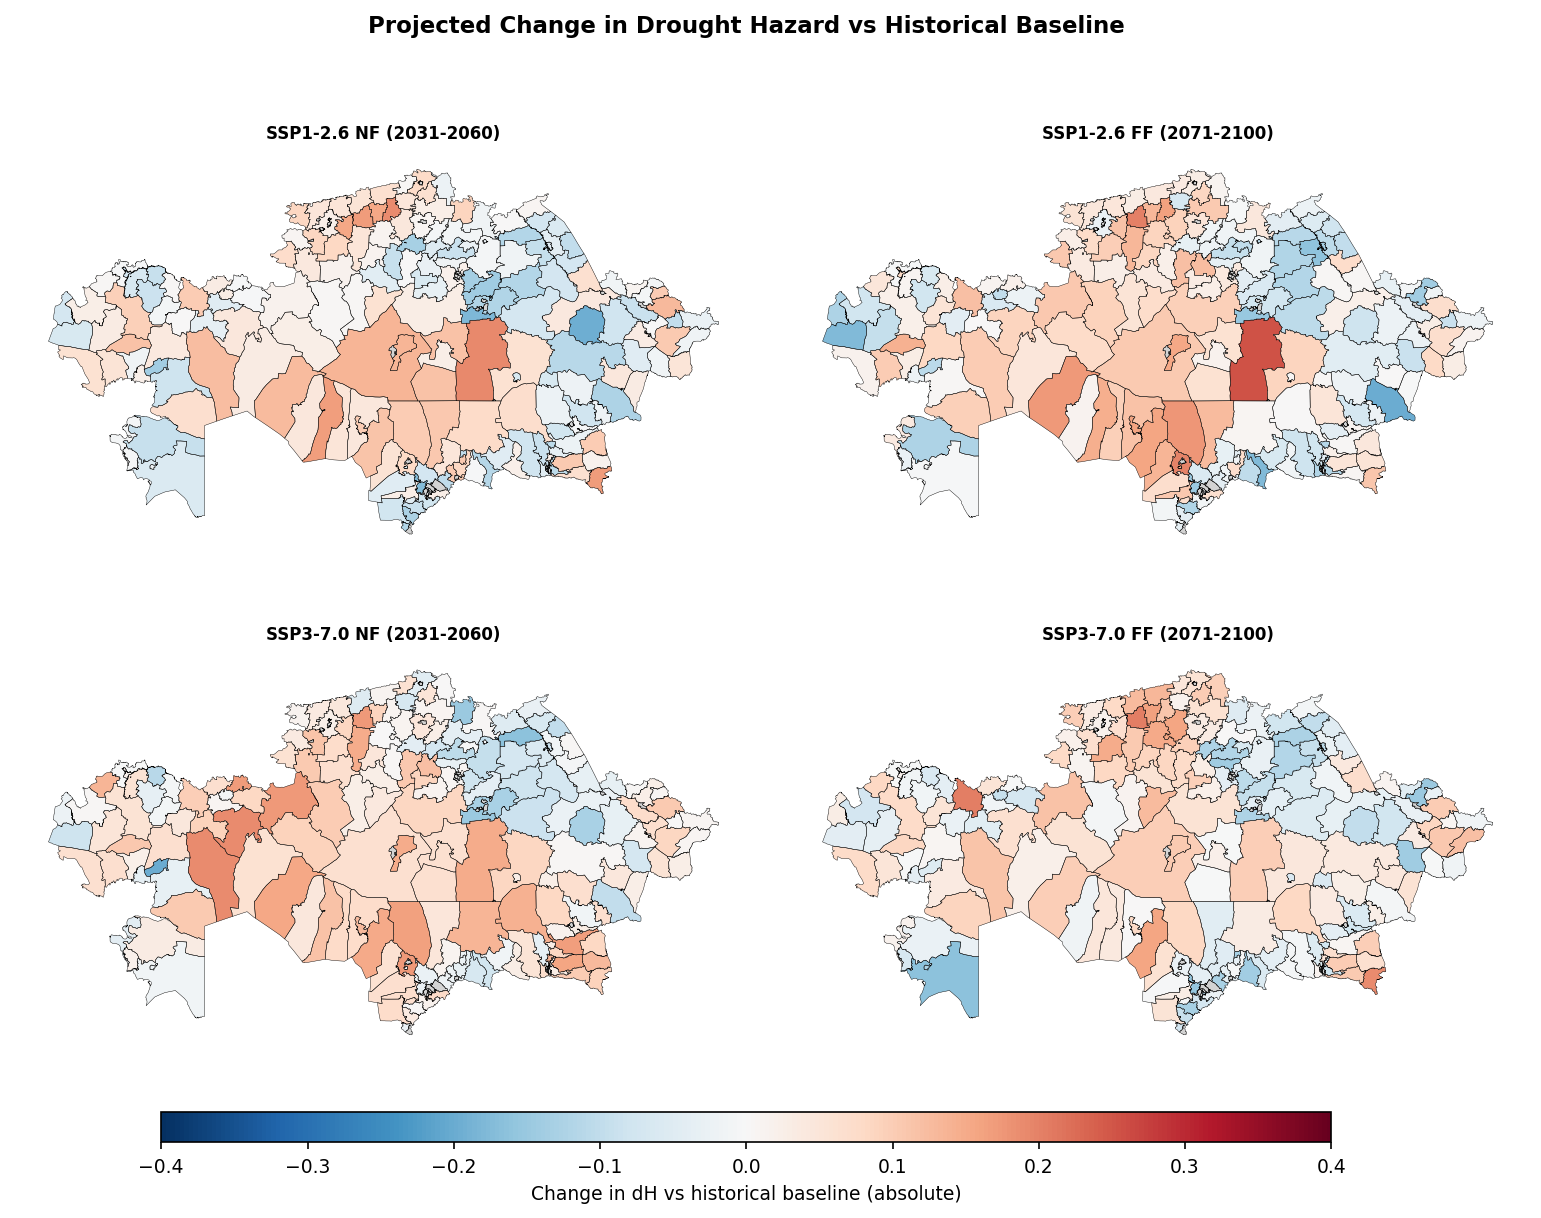

Figure 2 saved.


In [4]:
future = ['ssp126_nf', 'ssp126_ff', 'ssp370_nf', 'ssp370_ff']
norm_div = TwoSlopeNorm(vmin=-0.4, vcenter=0.0, vmax=0.4)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, scen in zip(axes.flat, future):
    delta = hazard_all.set_index('district')[scen] - hist_vals
    gdf_d = with_col(districts, hazard_all['district'], delta.values, 'delta')
    choropleth(ax, gdf_d, 'delta', 'RdBu_r', norm=norm_div,
               title=S_LABEL[scen])

fig.subplots_adjust(bottom=0.1, hspace=0.15, wspace=0.05)
sm_div = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm_div)
sm_div.set_array([])
cbar_ax = fig.add_axes([0.2, 0.04, 0.6, 0.025])
fig.colorbar(sm_div, cax=cbar_ax, orientation='horizontal',
             label='Change in dH vs historical baseline (absolute)')
fig.suptitle('Projected Change in Drought Hazard vs Historical Baseline',
             fontsize=11, fontweight='bold')
plt.savefig(FIG_DIR / 'fig02_dH_projected_change.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## Figure 3 — Drought hazard distribution across scenarios

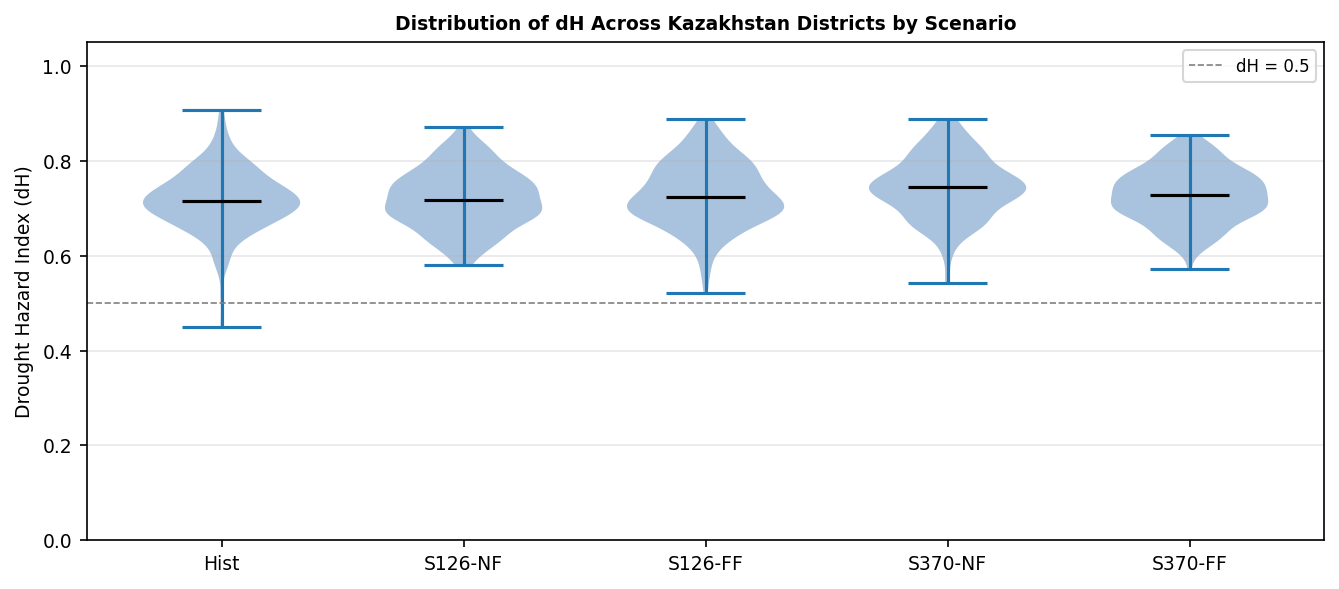

Figure 3 saved.


In [5]:
data_by_scen = [
    hazard_all[s].dropna().values for s in SCENARIOS if s in hazard_all.columns
]
labels_used = [s for s in SCENARIOS if s in hazard_all.columns]
positions = list(range(len(labels_used)))

fig, ax = plt.subplots(figsize=(9, 4))
parts = ax.violinplot(data_by_scen, positions=positions, showmedians=True,
                      showextrema=True, widths=0.65)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)
for pc in parts['bodies']:
    pc.set_facecolor('#8CAED2')
    pc.set_alpha(0.75)
ax.set_xticks(positions)
ax.set_xticklabels([S_SHORT[s] for s in labels_used])
ax.set_ylabel('Drought Hazard Index (dH)')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='dH = 0.5')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_title('Distribution of dH Across Kazakhstan Districts by Scenario',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_dH_violin_scenarios.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## Figure 4 — WASP event diagnostics (historical)

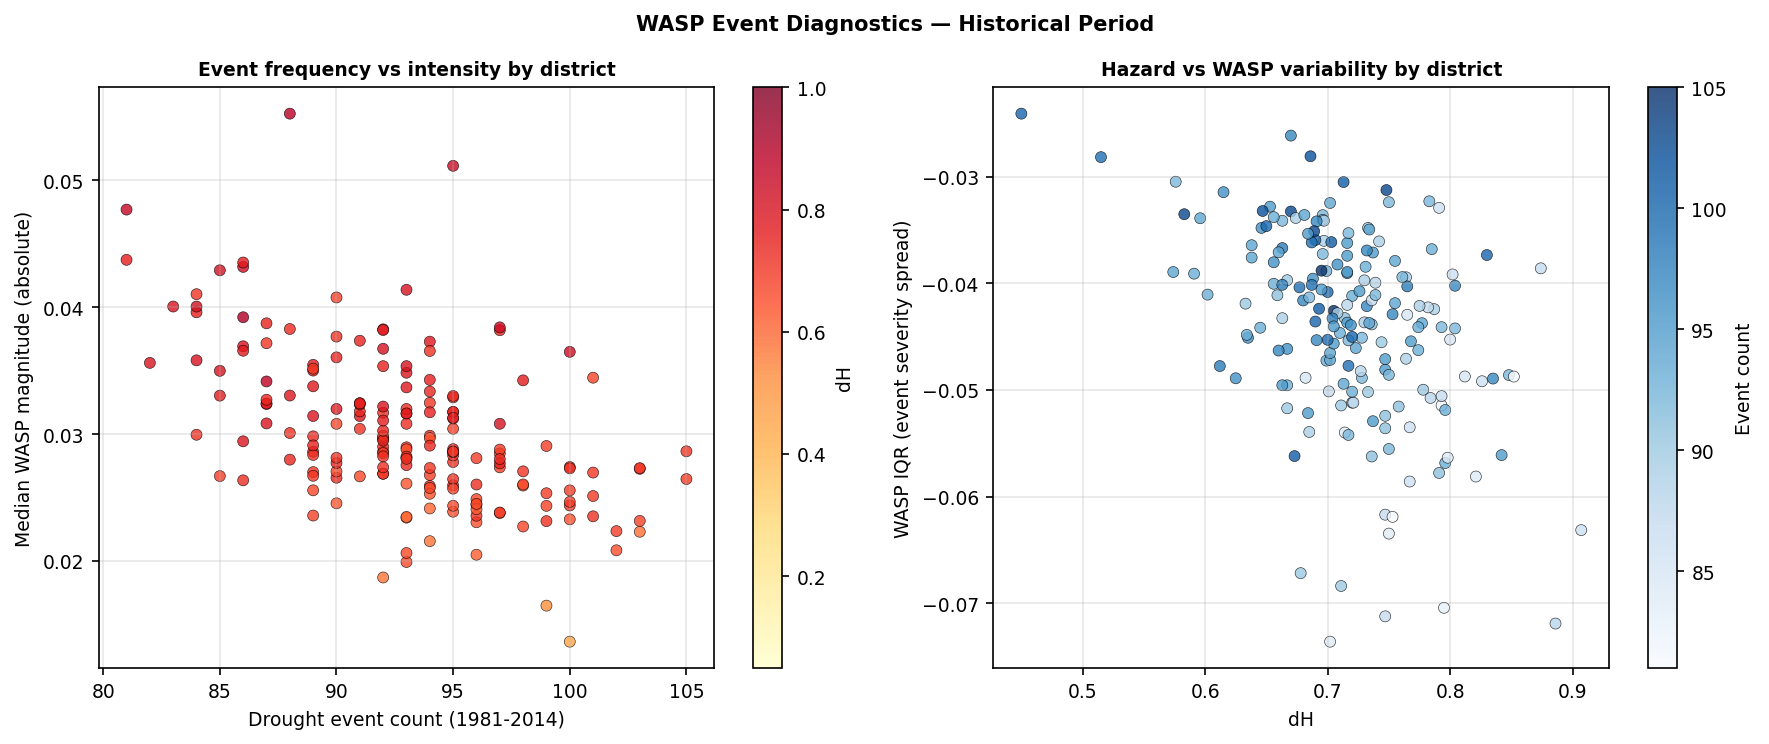

Figure 4 saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: event count vs |median WASP|, coloured by dH
ax = axes[0]
sc = ax.scatter(
    hazard_hist['wasp_raw_count'],
    hazard_hist['wasp_raw_median'].abs(),
    c=hazard_hist['hazard_raw'], cmap='YlOrRd', vmin=0.05, vmax=1.0,
    s=28, alpha=0.8, edgecolors='black', linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='dH')
ax.set_xlabel('Drought event count (1981-2014)')
ax.set_ylabel('Median WASP magnitude (absolute)')
ax.set_title('Event frequency vs intensity by district', fontweight='bold')
ax.grid(alpha=0.3)

# Right: WASP IQR (q75 - q25) vs dH
ax2 = axes[1]
iqr = hazard_hist['wasp_raw_q75'].abs() - hazard_hist['wasp_raw_q25'].abs()
sc2 = ax2.scatter(
    hazard_hist['hazard_raw'], iqr,
    c=hazard_hist['wasp_raw_count'], cmap='Blues',
    s=28, alpha=0.8, edgecolors='black', linewidths=0.3
)
plt.colorbar(sc2, ax=ax2, label='Event count')
ax2.set_xlabel('dH')
ax2.set_ylabel('WASP IQR (event severity spread)')
ax2.set_title('Hazard vs WASP variability by district', fontweight='bold')
ax2.grid(alpha=0.3)

fig.suptitle('WASP Event Diagnostics — Historical Period', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_wasp_diagnostics.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## Figure 5 — Risk class maps: historical vs SSP3-7.0 far-future

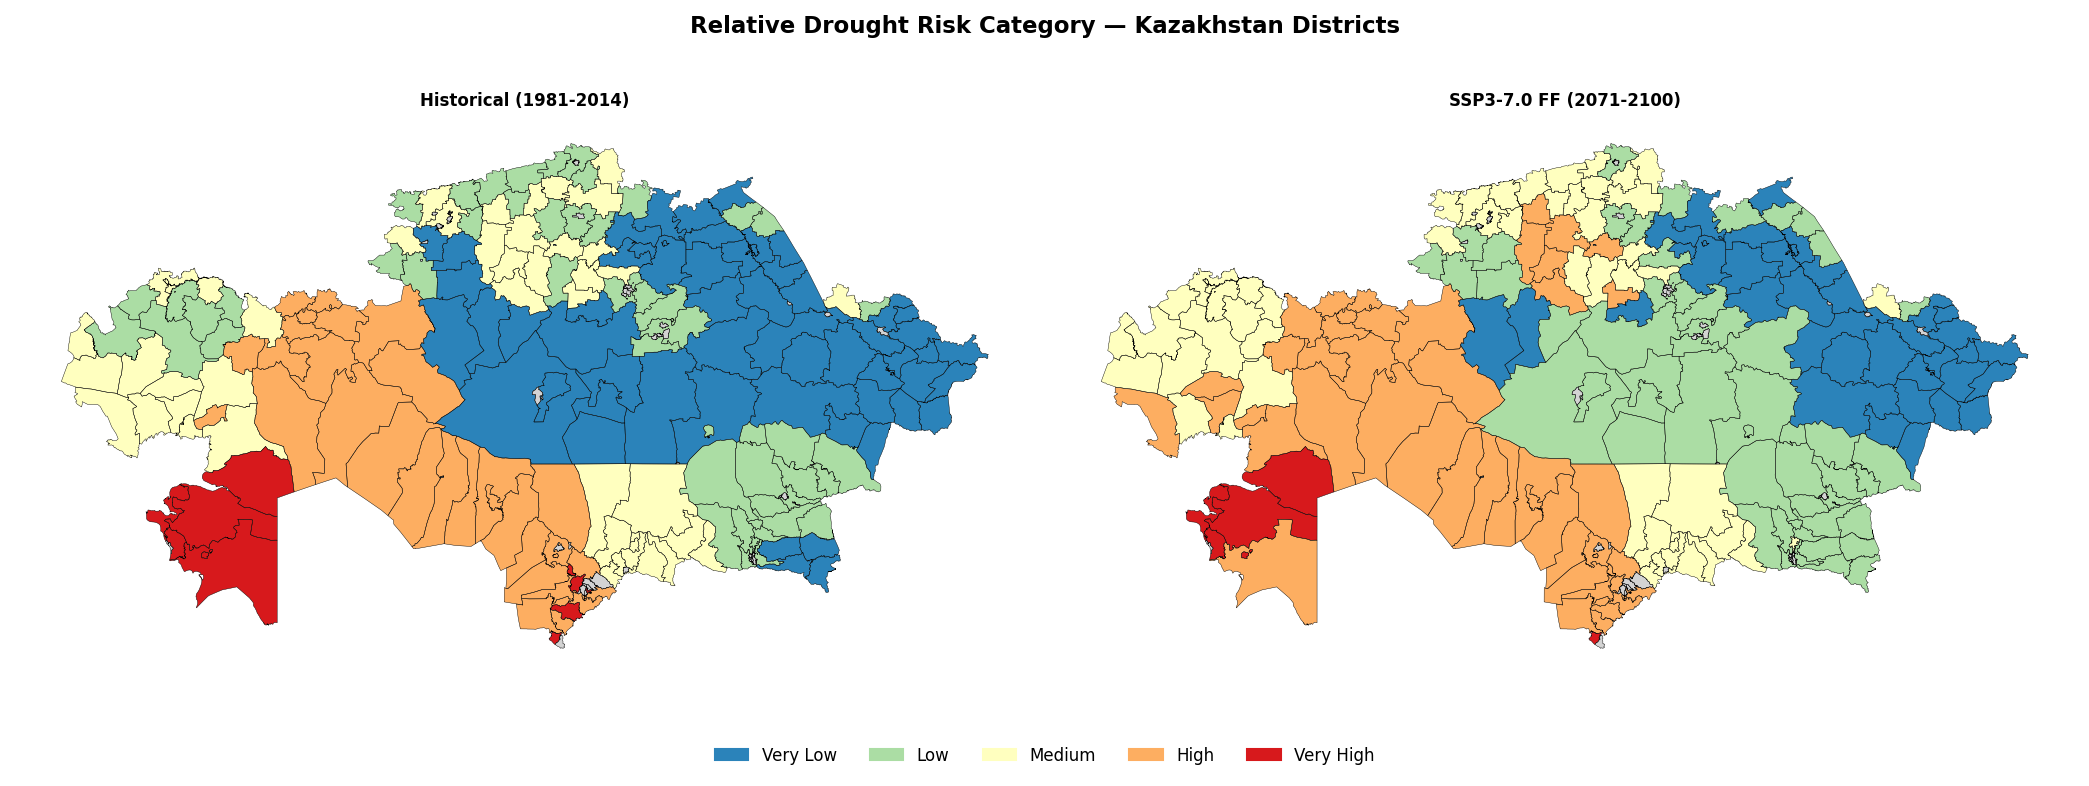

Figure 5 saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scen in zip(axes, ['historic', 'ssp370_ff']):
    if scen not in risk_tables:
        ax.set_visible(False)
        continue
    gdf_r = with_col(districts, risk_tables[scen]['district'],
                     risk_tables[scen]['risk_cat'], 'risk_cat')
    choropleth(ax, gdf_r, 'risk_cat', risk_cmap, norm=risk_norm, title=S_LABEL[scen])

patches = [mpatches.Patch(color=RISK_COLORS[i], label=RISK_LABELS[i]) for i in range(5)]
fig.legend(handles=patches, loc='lower center', ncol=5, frameon=False,
           fontsize=8, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Relative Drought Risk Category — Kazakhstan Districts',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_risk_class_maps.png', bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

## Figure 6 — Risk class distribution by scenario

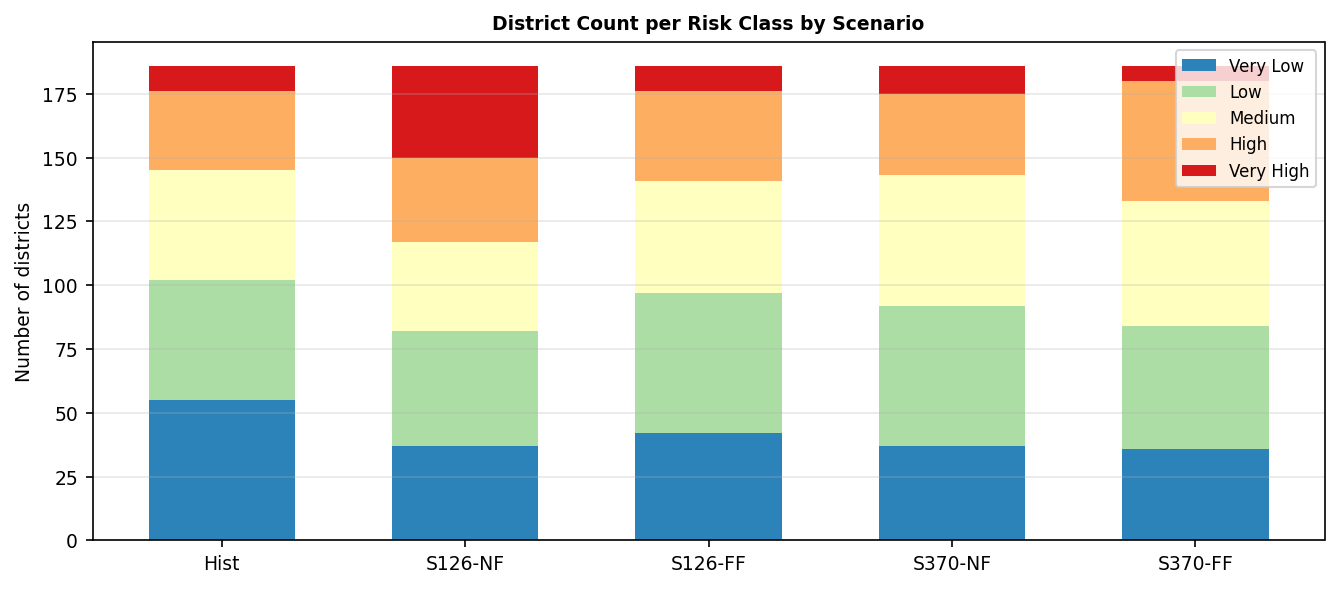

Figure 6 saved.


In [8]:
hist_counts = {}
for scen in SCENARIOS:
    if scen in risk_tables:
        counts = (risk_tables[scen]
                  .groupby('risk_cat', observed=False)
                  .size()
                  .reindex(range(1, 6), fill_value=0))
        hist_counts[scen] = counts.values

valid = [s for s in SCENARIOS if s in hist_counts]
bottom = np.zeros(len(valid))
x = np.arange(len(valid))

fig, ax = plt.subplots(figsize=(9, 4))
for i, (col, lbl) in enumerate(zip(RISK_COLORS, RISK_LABELS)):
    vals = [hist_counts[s][i] for s in valid]
    ax.bar(x, vals, bottom=bottom, color=col, label=lbl, width=0.6)
    bottom += np.array(vals, dtype=float)

ax.set_xticks(x)
ax.set_xticklabels([S_SHORT[s] for s in valid])
ax.set_ylabel('Number of districts')
ax.set_title('District Count per Risk Class by Scenario', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig06_risk_class_distribution.png', bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

## Figure 7 — Vulnerability components by oblast

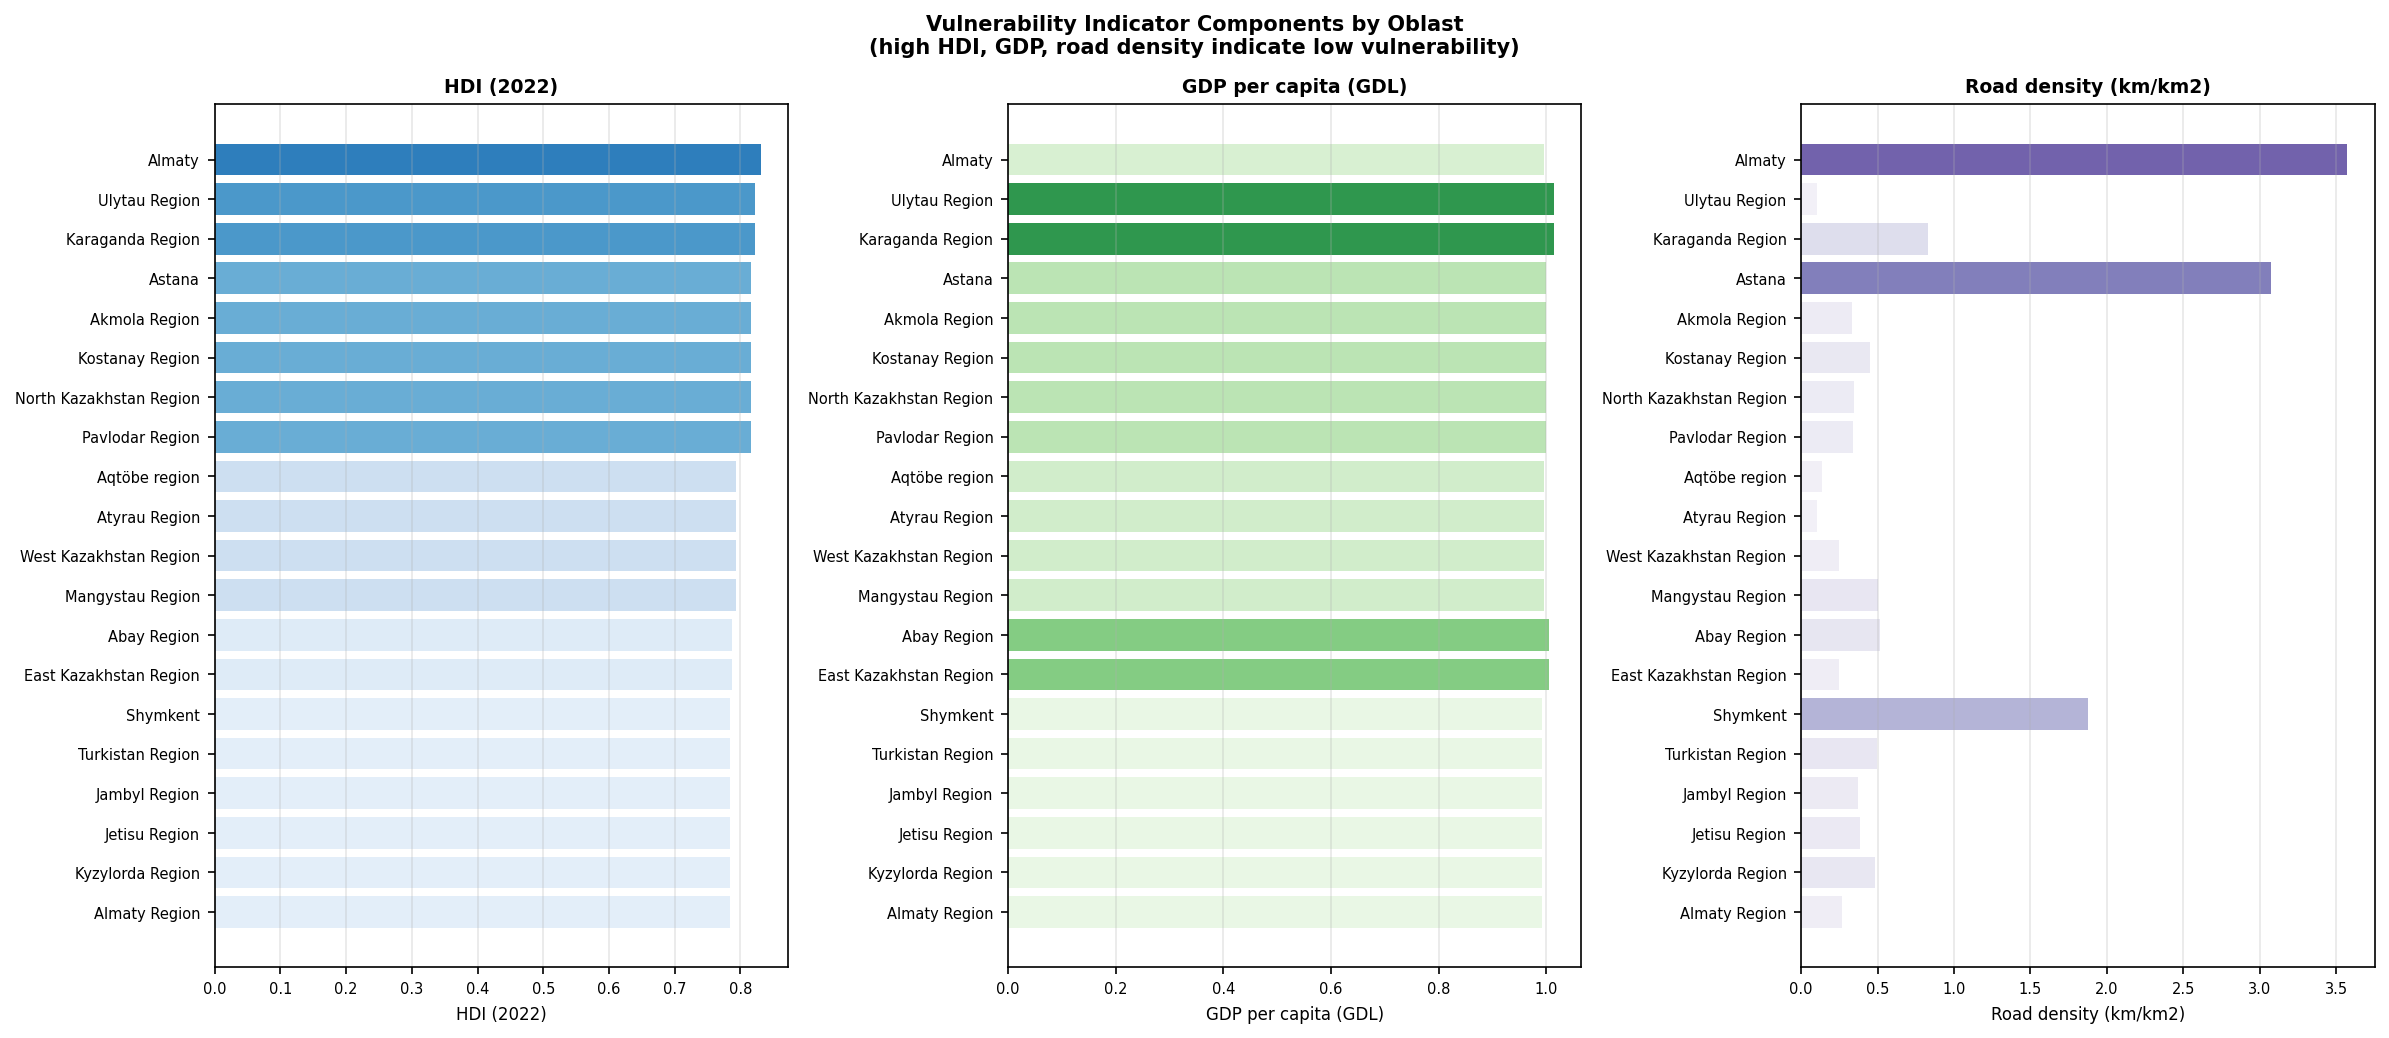

Figure 7 saved.


In [9]:
vuln_df['oblast'] = (vuln_df.index
                     .str.split(' | ', n=1, regex=False)
                     .str[1].str.strip())
vuln_ob = (vuln_df
           .groupby('oblast')[['hdi', 'gdp_pc', 'road_density_km_per_km2']]
           .mean()
           .sort_values('hdi'))

cols  = ['hdi', 'gdp_pc', 'road_density_km_per_km2']
xlabs = ['HDI (2022)', 'GDP per capita (GDL)', 'Road density (km/km2)']
cmaps = ['Blues_r', 'Greens_r', 'Purples_r']

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
for ax, col, xlab, cm in zip(axes, cols, xlabs, cmaps):
    vals   = vuln_ob[col]
    norm_c = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    colors = plt.get_cmap(cm)(0.3 + 0.6 * (1 - norm_c))
    ax.barh(vuln_ob.index, vals, color=colors)
    ax.set_xlabel(xlab, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_title(xlab, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Vulnerability Indicator Components by Oblast\n'
             '(high HDI, GDP, road density indicate low vulnerability)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig07_vulnerability_components.png', bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

## Figure 8 — Exposure vs vulnerability: risk components scatter

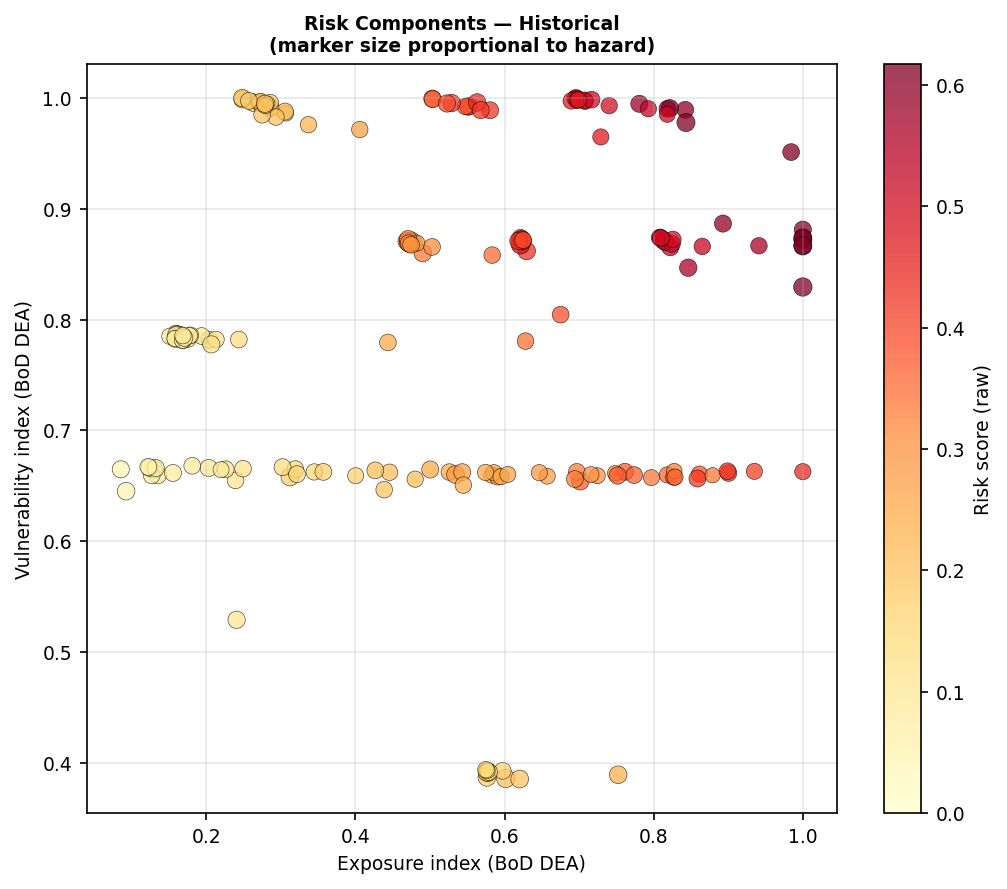

Figure 8 saved.


In [10]:
hist_risk = risk_tables.get('historic', pd.DataFrame())

fig, ax = plt.subplots(figsize=(7, 6))
if not hist_risk.empty:
    sc = ax.scatter(
        hist_risk['exposure_raw'],
        hist_risk['vulnerability_raw'],
        c=hist_risk['risk_raw'],
        cmap='YlOrRd',
        vmin=0, vmax=hist_risk['risk_raw'].quantile(0.95),
        s=hist_risk['hazard_raw'] * 80 + 8,
        alpha=0.75, edgecolors='black', linewidths=0.3
    )
    plt.colorbar(sc, ax=ax, label='Risk score (raw)')
    ax.set_xlabel('Exposure index (BoD DEA)')
    ax.set_ylabel('Vulnerability index (BoD DEA)')
    ax.set_title('Risk Components — Historical\n(marker size proportional to hazard)',
                 fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig08_risk_components_scatter.png', bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

## Figure 9 — Summary infographic panel

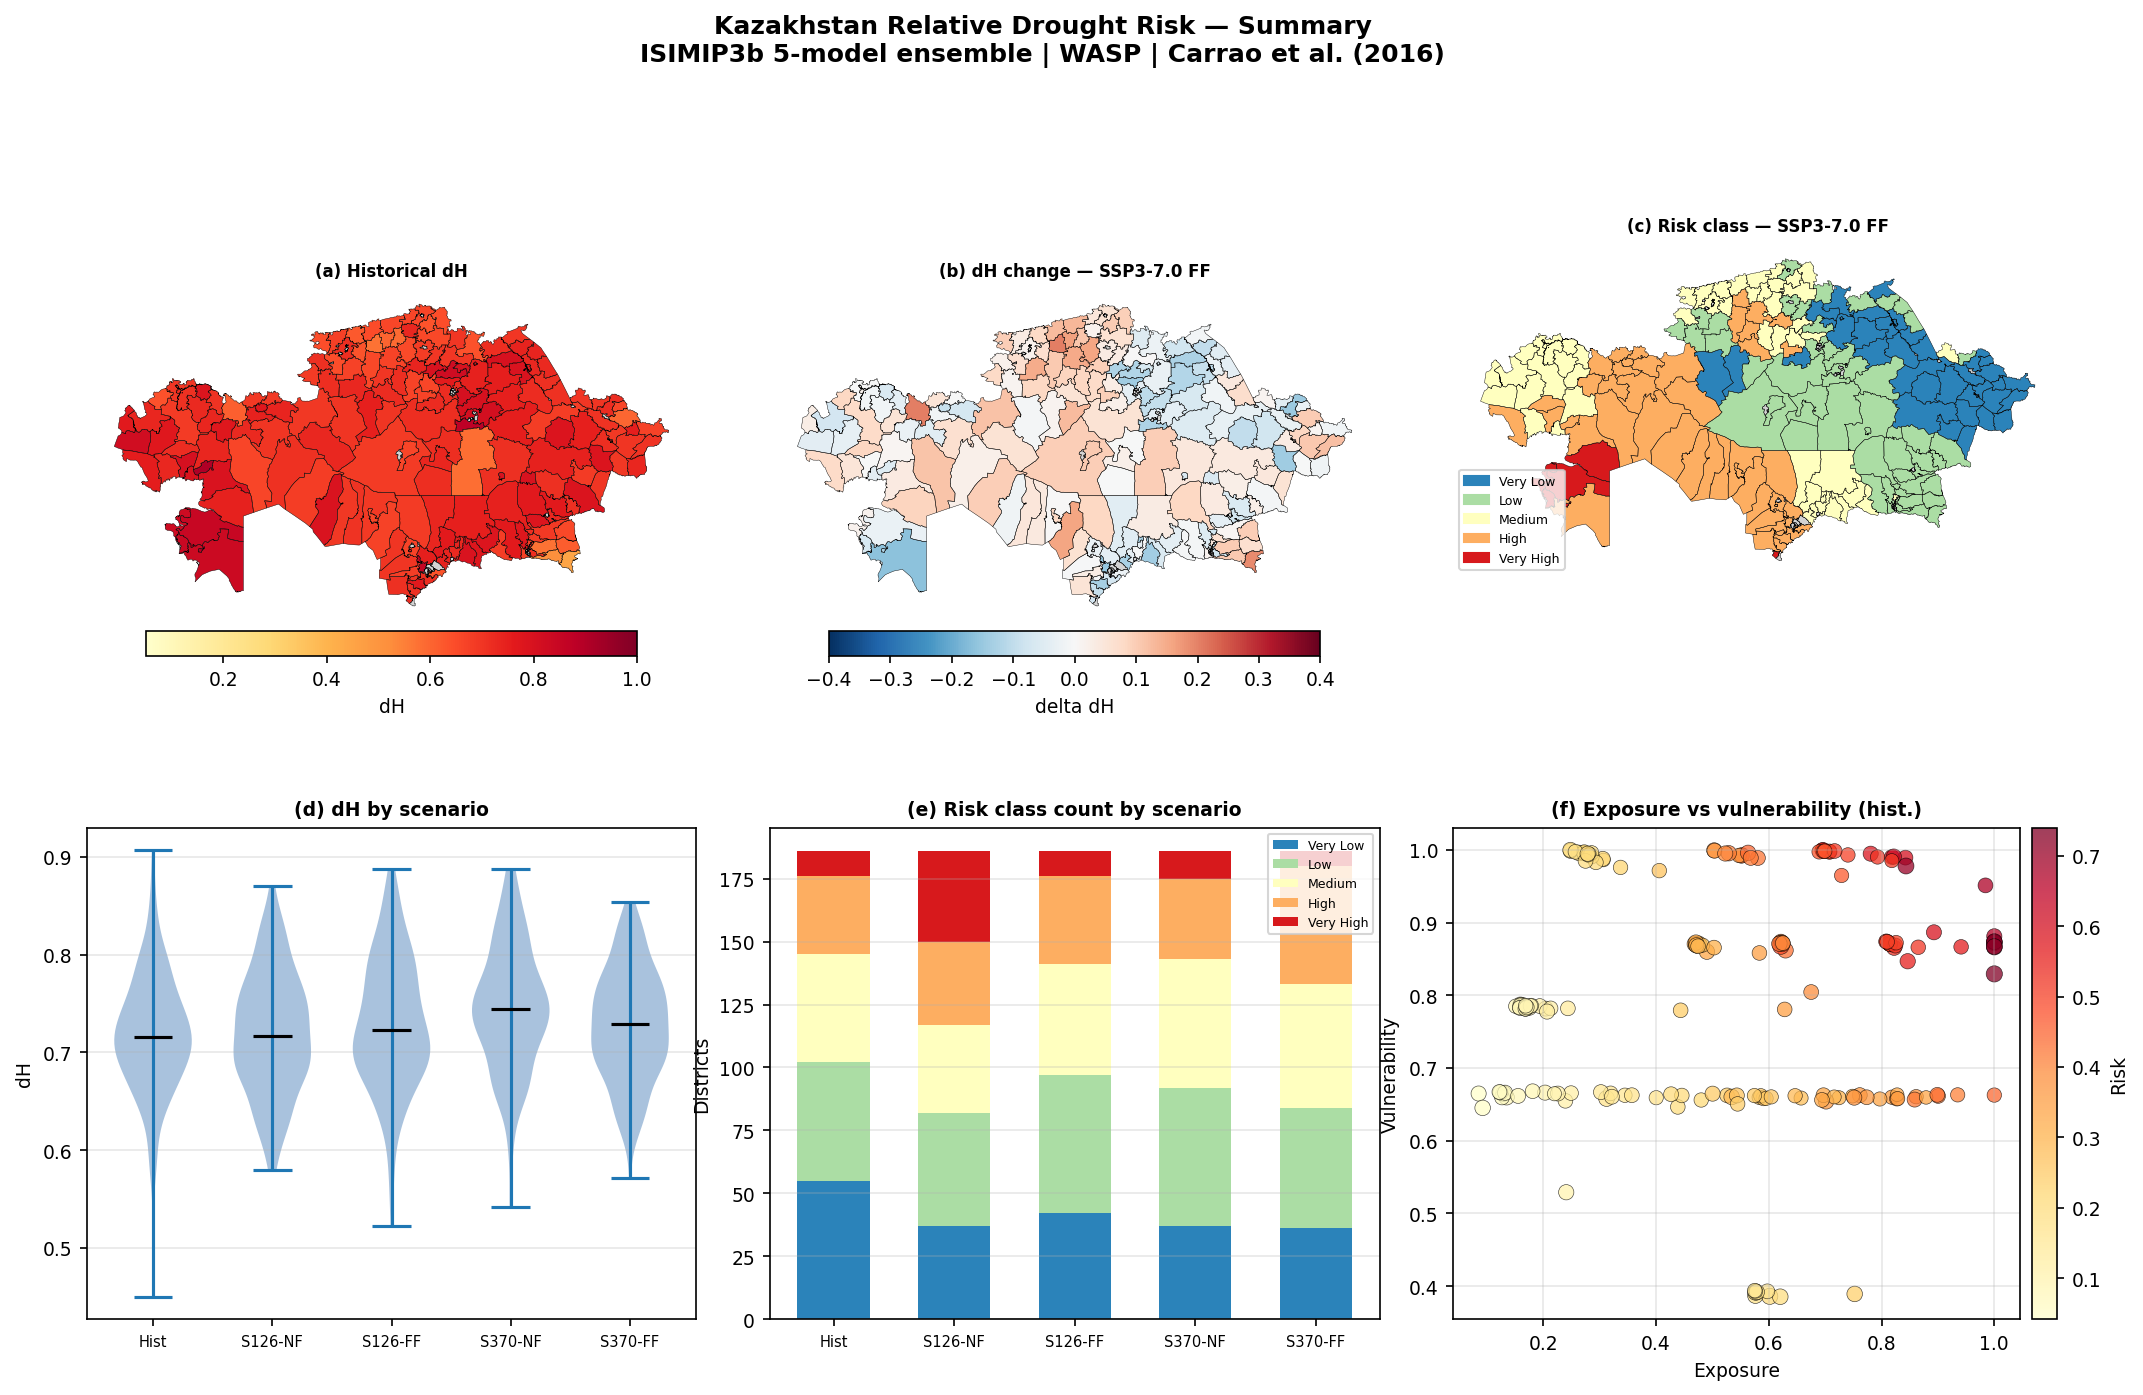

Figure 9 saved.

All figures saved to: report_figures\relative_drought


In [11]:
fig = plt.figure(figsize=(17, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.12)

# (a) dH historical
axA = fig.add_subplot(gs[0, 0])
choropleth(axA, gdf_h, 'dH', 'YlOrRd', vmin=0.05, vmax=1.0, title='(a) Historical dH')
smA = plt.cm.ScalarMappable(cmap='YlOrRd', norm=mcolors.Normalize(0.05, 1.0))
smA.set_array([])
plt.colorbar(smA, ax=axA, orientation='horizontal', fraction=0.05, pad=0.02, label='dH')

# (b) dH change SSP3-7.0 FF
axB = fig.add_subplot(gs[0, 1])
delta_ff = hazard_all.set_index('district')['ssp370_ff'] - hist_vals
gdf_ff   = with_col(districts, hazard_all['district'], delta_ff.values, 'delta')
choropleth(axB, gdf_ff, 'delta', 'RdBu_r', norm=norm_div,
           title='(b) dH change — SSP3-7.0 FF')
smB = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm_div)
smB.set_array([])
plt.colorbar(smB, ax=axB, orientation='horizontal', fraction=0.05, pad=0.02,
             label='delta dH')

# (c) Risk class map SSP3-7.0 FF
axC = fig.add_subplot(gs[0, 2])
if 'ssp370_ff' in risk_tables:
    gdf_rff = with_col(districts, risk_tables['ssp370_ff']['district'],
                       risk_tables['ssp370_ff']['risk_cat'], 'risk_cat')
    choropleth(axC, gdf_rff, 'risk_cat', risk_cmap, norm=risk_norm,
               title='(c) Risk class — SSP3-7.0 FF')
patches = [mpatches.Patch(color=RISK_COLORS[i], label=RISK_LABELS[i]) for i in range(5)]
axC.legend(handles=patches, loc='lower left', fontsize=6, frameon=True)

# (d) Violin
axD = fig.add_subplot(gs[1, 0])
parts2 = axD.violinplot(data_by_scen, positions=positions, showmedians=True, widths=0.65)
parts2['cmedians'].set_color('black')
for pc in parts2['bodies']:
    pc.set_facecolor('#8CAED2')
    pc.set_alpha(0.75)
axD.set_xticks(positions)
axD.set_xticklabels([S_SHORT[s] for s in labels_used], fontsize=7)
axD.set_ylabel('dH')
axD.set_title('(d) dH by scenario', fontweight='bold')
axD.grid(axis='y', alpha=0.3)

# (e) Stacked bar
axE = fig.add_subplot(gs[1, 1])
bot = np.zeros(len(valid))
for i, (col, lbl) in enumerate(zip(RISK_COLORS, RISK_LABELS)):
    v = [hist_counts[s][i] for s in valid]
    axE.bar(range(len(valid)), v, bottom=bot, color=col, label=lbl, width=0.6)
    bot += np.array(v, dtype=float)
axE.set_xticks(range(len(valid)))
axE.set_xticklabels([S_SHORT[s] for s in valid], fontsize=7)
axE.set_ylabel('Districts')
axE.set_title('(e) Risk class count by scenario', fontweight='bold')
axE.legend(fontsize=6, loc='upper right')
axE.grid(axis='y', alpha=0.3)

# (f) E vs V scatter
axF = fig.add_subplot(gs[1, 2])
if not hist_risk.empty:
    sc2 = axF.scatter(
        hist_risk['exposure_raw'], hist_risk['vulnerability_raw'],
        c=hist_risk['risk_raw'], cmap='YlOrRd',
        s=hist_risk['hazard_raw'] * 60 + 8,
        alpha=0.75, edgecolors='black', linewidths=0.3
    )
    plt.colorbar(sc2, ax=axF, label='Risk', fraction=0.05, pad=0.02)
    axF.set_xlabel('Exposure')
    axF.set_ylabel('Vulnerability')
    axF.set_title('(f) Exposure vs vulnerability (hist.)', fontweight='bold')
    axF.grid(alpha=0.3)

fig.suptitle('Kazakhstan Relative Drought Risk — Summary\n'
             'ISIMIP3b 5-model ensemble | WASP | Carrao et al. (2016)',
             fontsize=12, fontweight='bold')
plt.savefig(FIG_DIR / 'fig09_summary_infographic.png', bbox_inches='tight', dpi=200)
plt.show()
print('Figure 9 saved.')
print(f'\nAll figures saved to: {FIG_DIR}')